In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Configuración para que las imágenes se vean grandes en VS Code
plt.rcParams['figure.figsize'] = [10, 10]

def mostrar(img, titulo="Procesamiento de Dados"):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.title(titulo)
    plt.axis('off')
    plt.show()

In [17]:
# Dados de colores
def analizar_dados_colores(ruta):
    img = cv2.imread(ruta)
    if img is None: return None, 0
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    blur = cv2.GaussianBlur(gray, (5,5), 0)
    
    _, thresh = cv2.threshold(blur, 100, 255, cv2.THRESH_BINARY_INV)
    
    kernel = np.ones((5,5), np.uint8)
    morf = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)
    
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(morf)
    
    copia = img.copy()
    dados_totales = 0
    
    for i in range(1, num_labels):
        x, y, w, h, area = stats[i]
        
        if 800 < area < 50000:
            dados_totales += 1
            cv2.rectangle(copia, (x,y), (x+w, y+h), (0,255,0), 2)
            
            roi = gray[y:y+h, x:x+w]
            roi_blur = cv2.medianBlur(roi, 5)
            _, puntos = cv2.threshold(roi, 197, 255, cv2.THRESH_BINARY)
            
            puntos = cv2.morphologyEx(puntos, cv2.MORPH_OPEN, np.ones((3,3), np.uint8))
            
            n_comp, _, stats_p, _ = cv2.connectedComponentsWithStats(puntos)
            
            valor = 0
            for j in range(1, n_comp):
                area_p = stats_p[j, cv2.CC_STAT_AREA]
                if 20 < area_p < 300:
                    valor += 1
            
            cv2.putText(copia, f"Val: {valor}", (x, y-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,0,0), 2)
    
    return copia, dados_totales

In [18]:
# Dados blancos y negros
import cv2
import numpy as np
 #3: Dados blancos (Ultrarrubusta)
def analizar_dados_blancos(ruta):
    img = cv2.imread(ruta)
    if img is None: return None, 0
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    blur = cv2.bilateralFilter(gray, 9, 75, 75)
    
    edged = cv2.Canny(blur, 50, 150)
    

    kernel_dil = np.ones((5,5), np.uint8)
    dilated = cv2.dilate(edged, kernel_dil, iterations=5)

    kernel_close = np.ones((11,11), np.uint8)
    morf = cv2.morphologyEx(dilated, cv2.MORPH_CLOSE, kernel_close)
    
   
    cnts, _ = cv2.findContours(morf.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    copia = img.copy()
    dados_totales = 0
    
    for c in cnts:
        area = cv2.contourArea(c)
        
        if 1500 < area < 60000:
            
            x, y, w, h = cv2.boundingRect(c)
         
            aspect_ratio = float(w)/h
            if 0.7 > aspect_ratio or aspect_ratio > 1.3:
                continue 

            dados_totales += 1
            cv2.rectangle(copia, (x,y), (x+w, y+h), (0,255,0), 3)
            
      
            roi = gray[y:y+h, x:x+w]
            
            
            _, puntos = cv2.threshold(roi, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
            
            puntos = cv2.medianBlur(puntos, 5)
            
            cnts_p, _ = cv2.findContours(puntos, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            
            valor = 0
            for cp in cnts_p:
                area_p = cv2.contourArea(cp)
                
              
                if 50 < area_p < 1000:
                    valor += 1
                    (px, py), radius = cv2.minEnclosingCircle(cp)
                    cv2.circle(copia, (int(px+x), int(py+y)), int(radius), (255,0,0), 2)
            
            cv2.putText(copia, f"Suma: {valor}", (x, y-15),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0,0,255), 3)
    
    return copia, dados_totales

--- Imagen 1.jpg (COLORES) ---


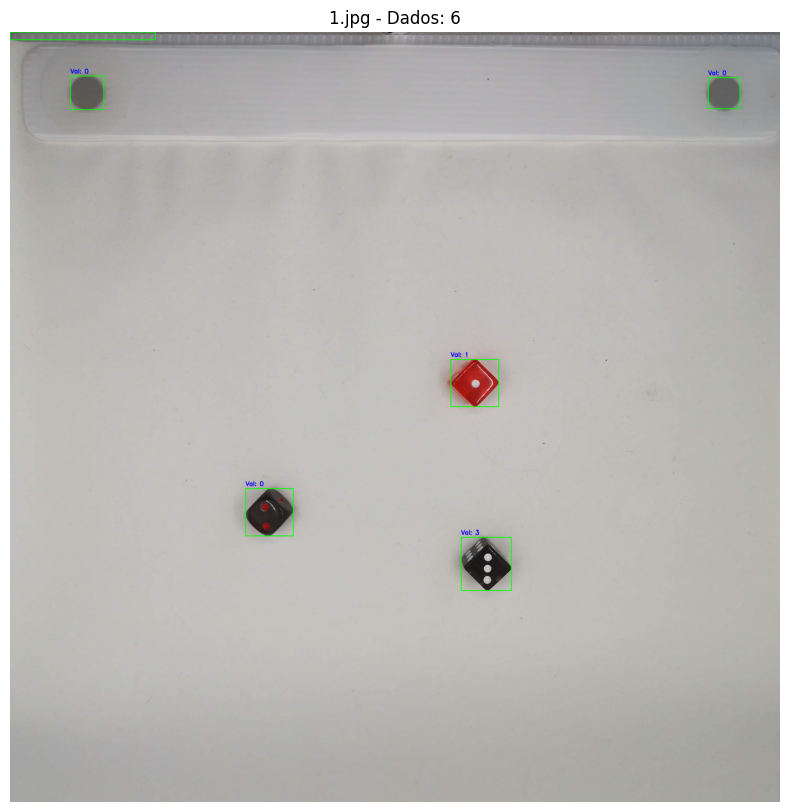

--- Imagen 2.jpg (COLORES) ---


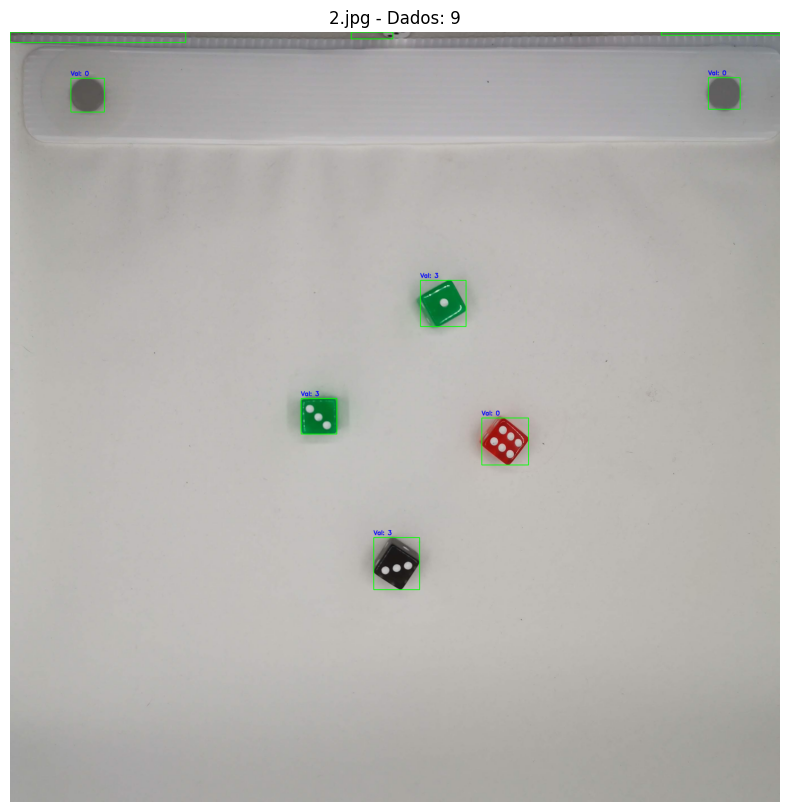

--- Imagen 3.jpg (COLORES) ---


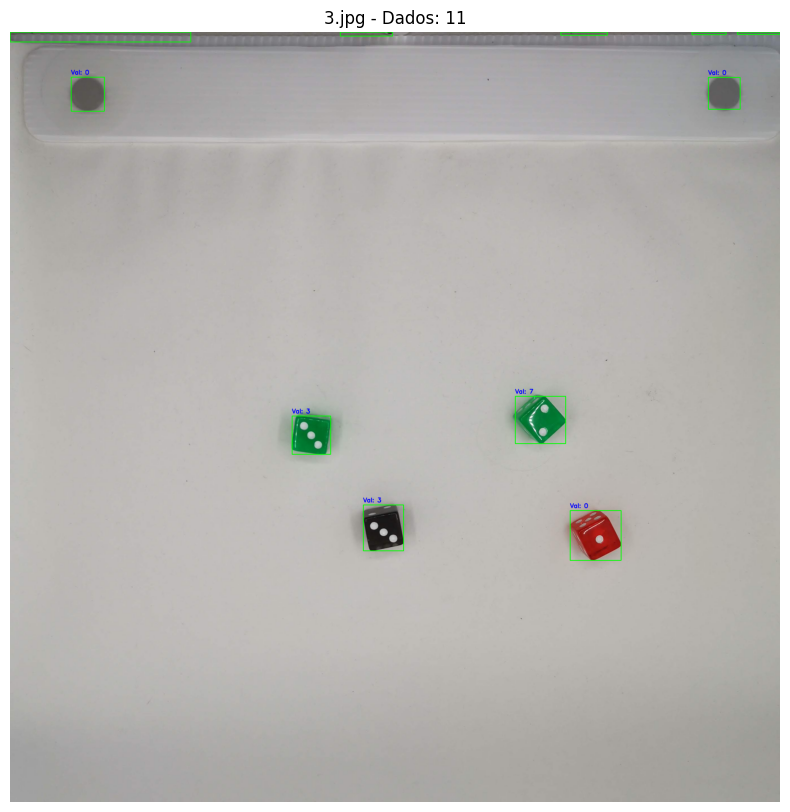

--- Imagen 4.jpg (COLORES) ---


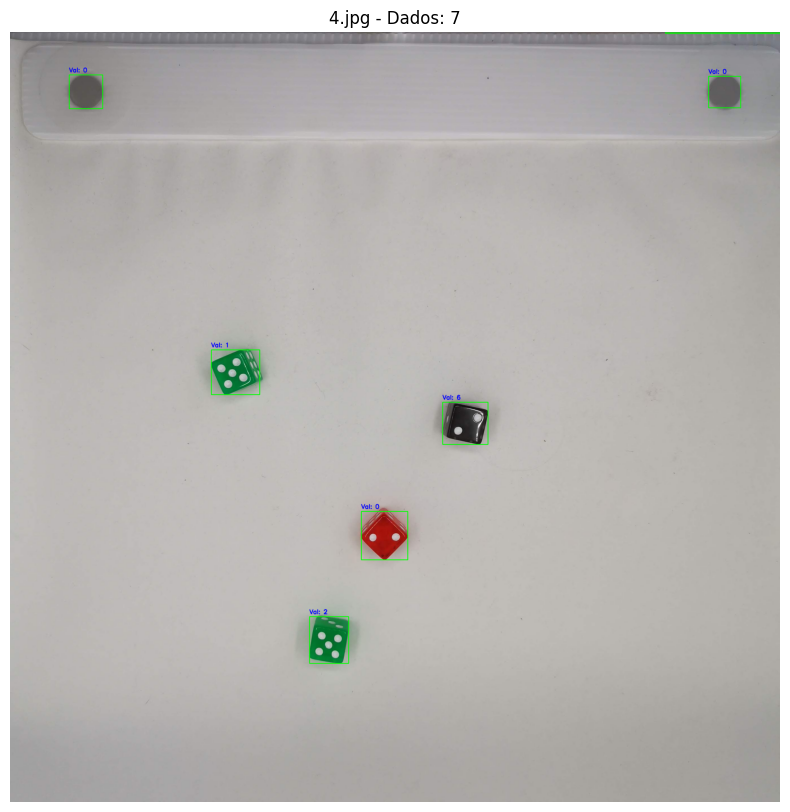

--- Imagen 5.jpg (COLORES) ---


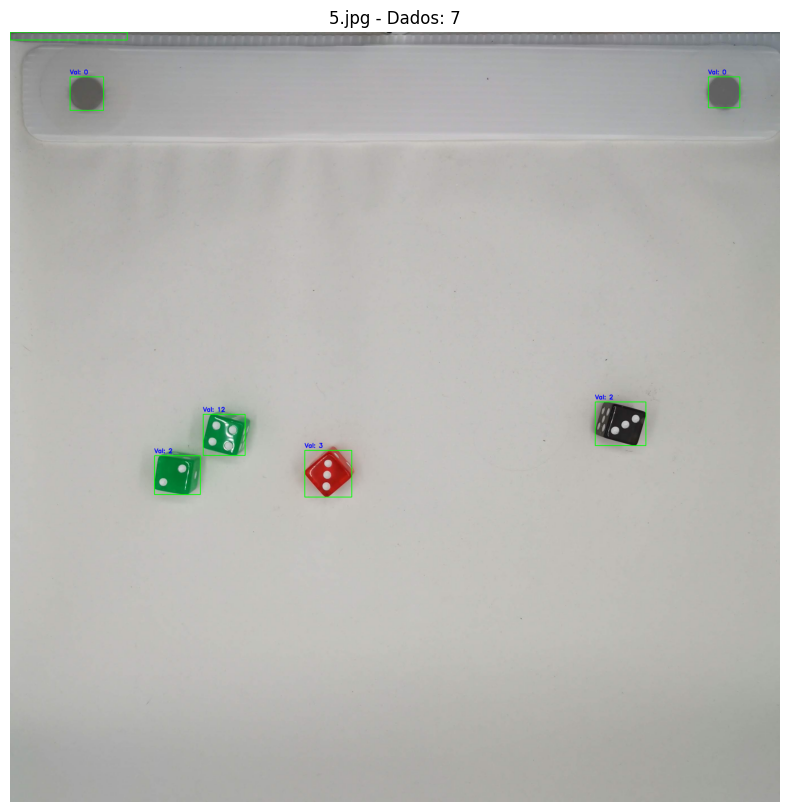

--- Imagen 6.jpg (COLORES) ---


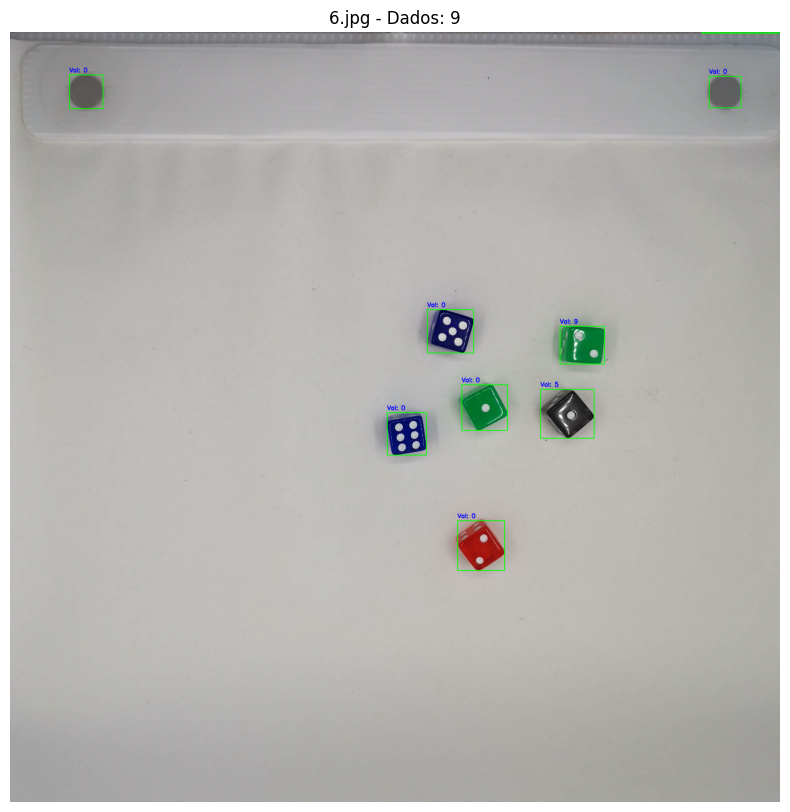

--- Imagen 7.jpg (COLORES) ---


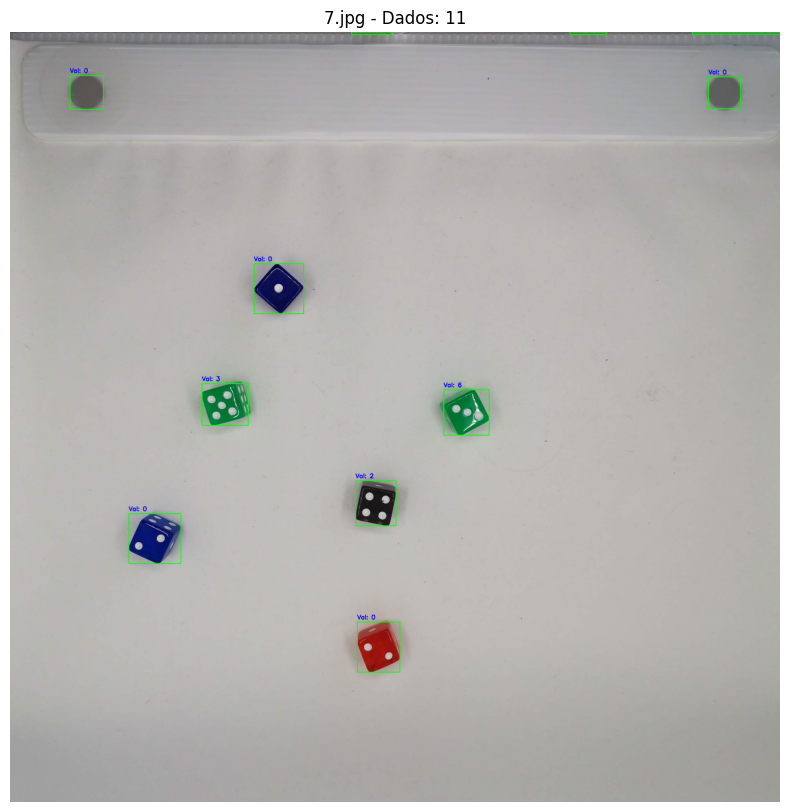

--- Imagen 8.jpg (COLORES) ---


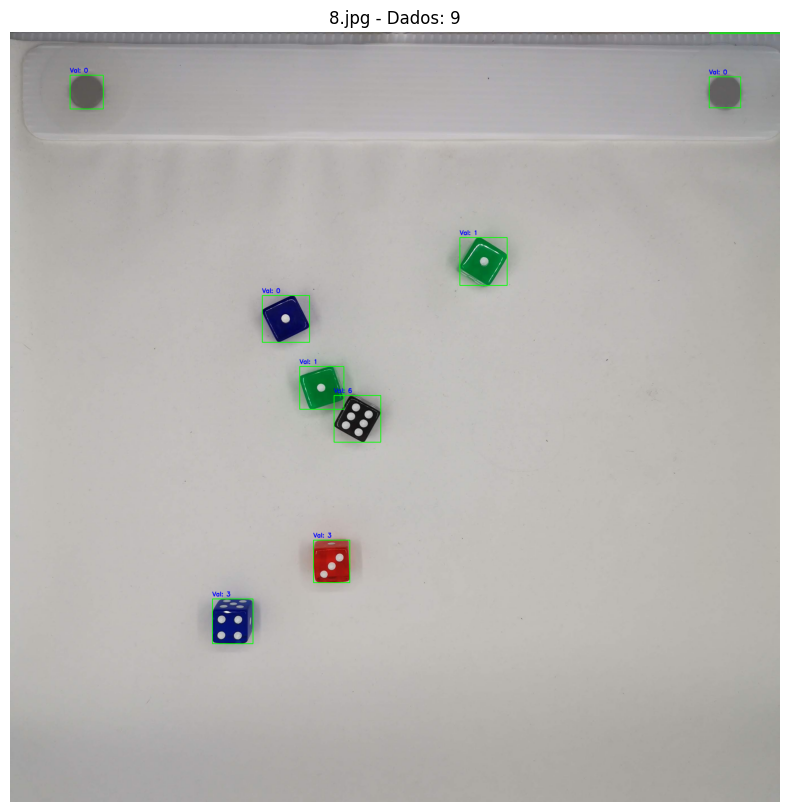

--- Imagen 9.jpg (BLANCOS) ---


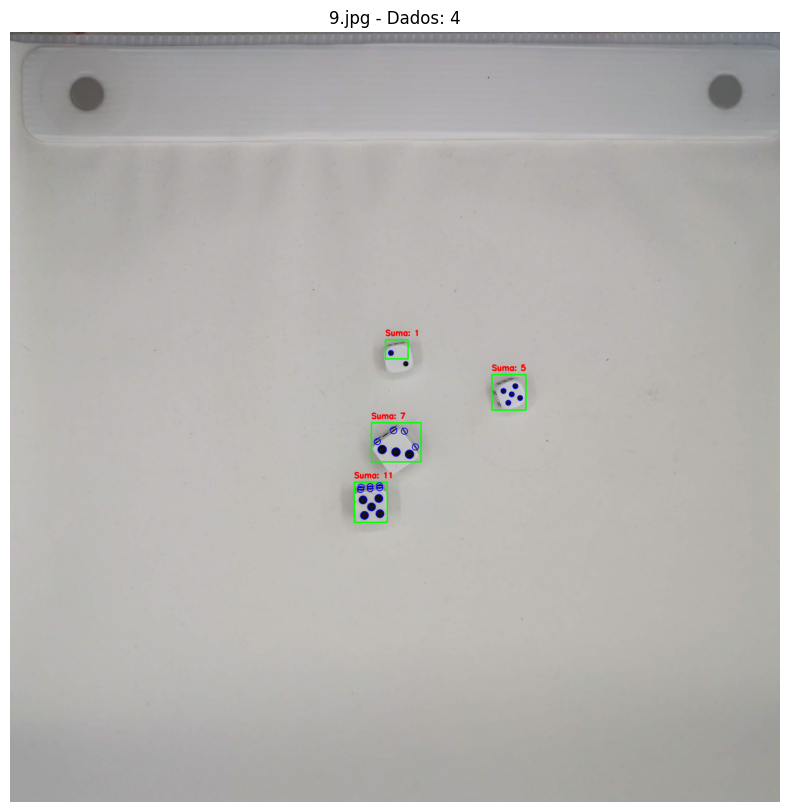

--- Imagen 10.jpg (BLANCOS) ---


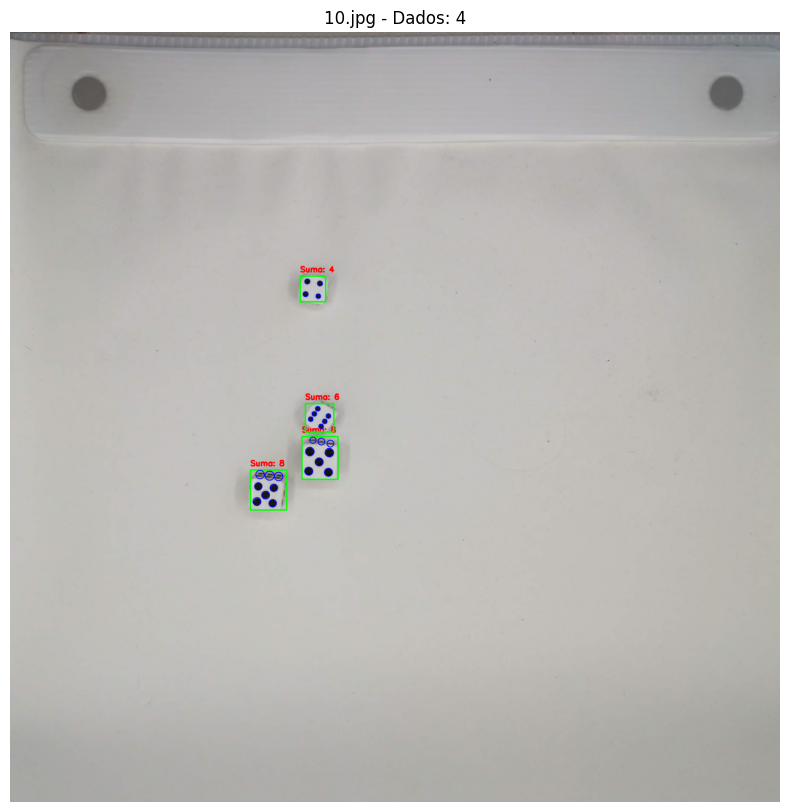

--- Imagen 11.jpg (BLANCOS) ---


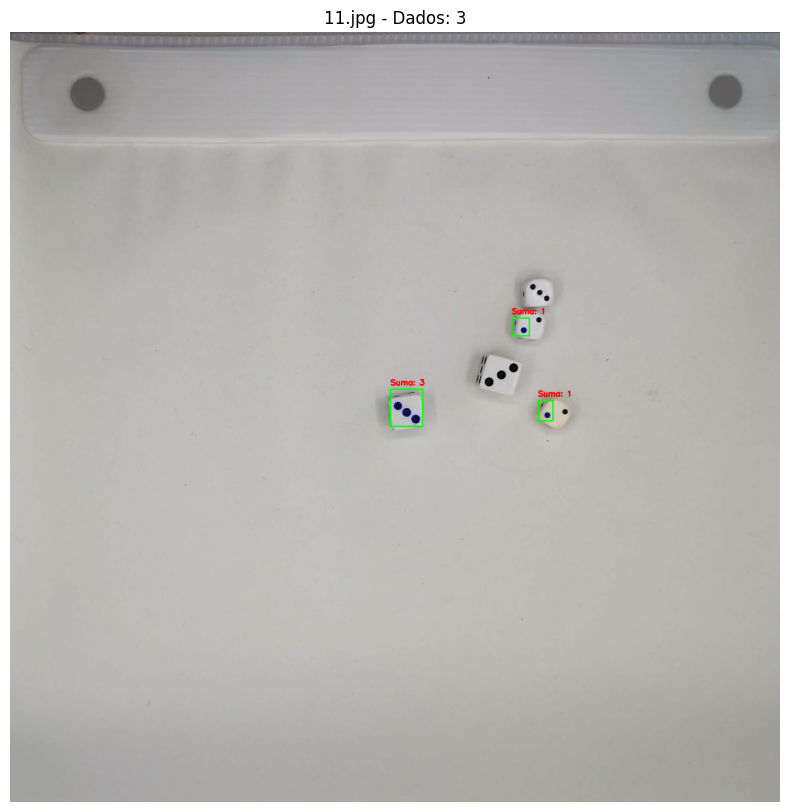

--- Imagen 12.jpg (BLANCOS) ---


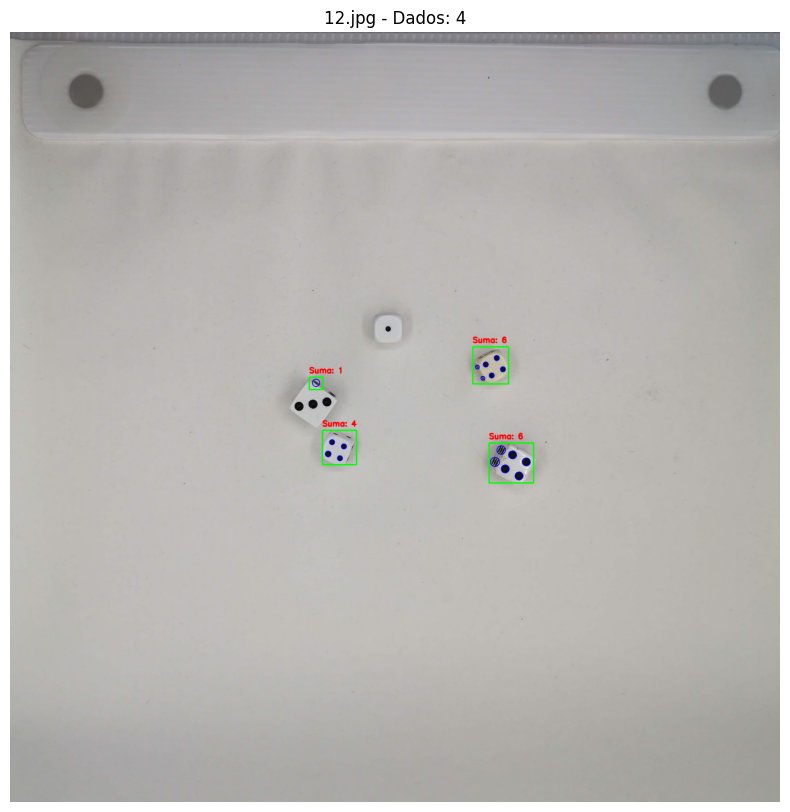

--- Imagen 13.jpg (BLANCOS) ---


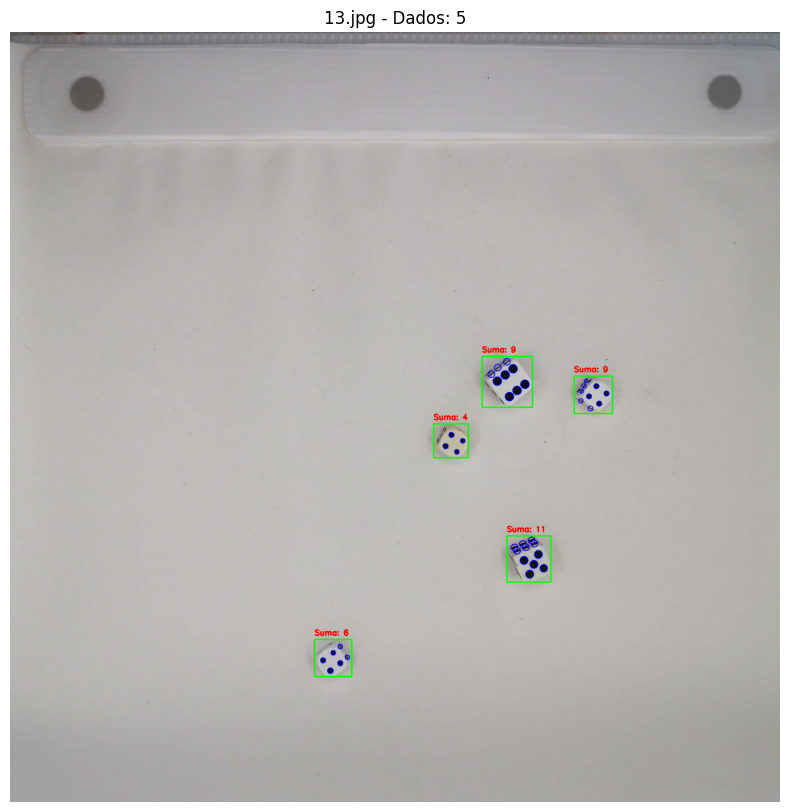

--- Imagen 14.jpg (BLANCOS) ---


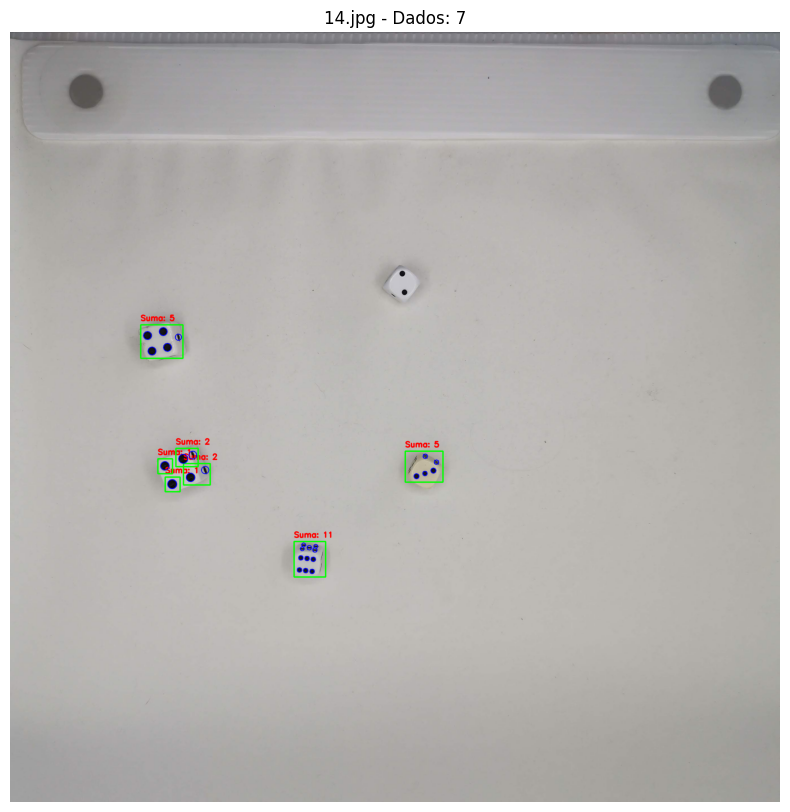

--- Imagen 15.jpg (BLANCOS) ---


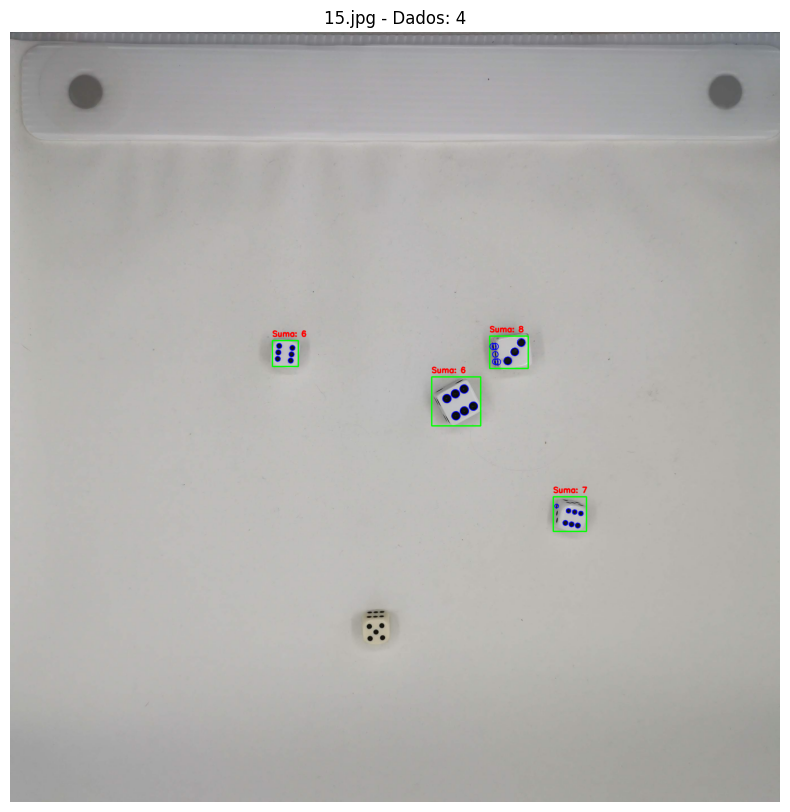

In [19]:
folder = 'img'

# Imágenes 1 a 8 -> dados de colores
for i in range(1, 9):
    nombre = f"{i}.jpg"
    ruta = os.path.join(folder, nombre)
    
    if os.path.exists(ruta):
        print(f"--- Imagen {nombre} (COLORES) ---")
        img, total = analizar_dados_colores(ruta)
        mostrar(img, f"{nombre} - Dados: {total}")

# Imágenes 9 a 15 -> dados blancos
for i in range(9, 16):
    nombre = f"{i}.jpg"
    ruta = os.path.join(folder, nombre)
    
    if os.path.exists(ruta):
        print(f"--- Imagen {nombre} (BLANCOS) ---")
        img, total = analizar_dados_blancos(ruta)
        mostrar(img, f"{nombre} - Dados: {total}")

In [20]:
import numpy as np


valores_reales = {
    "dado1.jpg": 15, "dado2.jpg": 10, "dado3.jpg": 12, "dado4.jpg": 8, 
    "dado5.jpg": 20, "dado6.jpg": 5,  "dado7.jpg": 18, "dado8.jpg": 14, # Colores
    "dado9.jpg": 10, "dado10.jpg": 12, "dado11.jpg": 15, "dado12.jpg": 21, 
    "dado13.jpg": 24, "dado14.jpg": 11, "dado15.jpg": 9            # Blancos
}

resultados_deteccion = []
errores_absolutos = []

print(f"{'Imagen':<12} | {'Real':<5} | {'Detectado':<10} | {'Error'}")
print("-" * 40)

for nombre, real in valores_reales.items():
    ruta = os.path.join(folder, nombre)
    if not os.path.exists(ruta): continue
    
    num_img = int(nombre.split('.')[0])
    if num_img < dado1:
        _, suma_detectada = analizar_dados_colores(ruta)
    else:
        _, suma_detectada = analizar_dados_blancos(ruta)
    
    error = abs(real - suma_detectada)
    errores_absolutos.append(error)
    resultados_deteccion.append(suma_detectada)
    
    print(f"{nombre:<12} | {real:<5} | {suma_detectada:<10} | {error}")

mae = np.mean(errores_absolutos) # Mean Absolute Error
mse = np.mean(np.square(errores_absolutos)) # Mean Squared Error

print("-" * 40)
print(f"Error Absoluto Medio (MAE): {mae:.2f} puntos")
print(f"Error Cuadrático Medio (MSE): {mse:.2f}")

Imagen       | Real  | Detectado  | Error
----------------------------------------
----------------------------------------
Error Absoluto Medio (MAE): nan puntos
Error Cuadrático Medio (MSE): nan
